In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [4]:
df = pd.read_csv("C:/Users/Dell/Desktop/DA/Analytics Projects/Data Projects/Python Projects/Student Performance Python Project/student_performance.csv")

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Student_ID        150 non-null    object 
 1   Gender            150 non-null    object 
 2   Age               150 non-null    int64  
 3   Study_Hours       150 non-null    float64
 4   Attendance        149 non-null    float64
 5   Math_Score        150 non-null    float64
 6   Science_Score     149 non-null    float64
 7   English_Score     150 non-null    float64
 8   Computer_Score    150 non-null    float64
 9   Assignment_Score  149 non-null    float64
 10  Previous_Score    149 non-null    float64
 11  Final_Score       150 non-null    float64
dtypes: float64(9), int64(1), object(2)
memory usage: 14.2+ KB


In [6]:
df.head()

,Student_ID,Gender,Age,Study_Hours,Attendance,Math_Score,Science_Score,English_Score,Computer_Score,Assignment_Score,Previous_Score,Final_Score
0,STU001,Male,21,5.4,84.5,36.3,41.7,32.4,43.8,87.2,65.2,73.3
1,STU002,Male,18,4.3,85.5,41.4,23.5,26.3,34.7,89.2,63.1,64.3
2,STU003,Female,18,5.7,75.2,32.7,46.4,35.8,44.8,93.3,77.3,77.4
3,STU004,Female,18,7.2,84.3,51.4,57.5,56.7,61.5,100.0,83.9,94.7
4,STU005,Female,19,4.1,84.9,30.2,36.2,29.8,40.0,81.4,66.5,67.0


#Number of Students and Number of parameters : 

In [8]:
df.shape

(150, 12)

In [9]:
df.describe()

,Age,Study_Hours,Attendance,Math_Score,Science_Score,English_Score,Computer_Score,Assignment_Score,Previous_Score,Final_Score
count,150.000000,150.000000,149.000000,150.000000,149.000000,150.000000,150.000000,149.000000,149.000000,150.000000
mean,20.026667,4.364000,82.397315,34.707333,33.706040,38.618667,40.314000,85.517450,67.685235,69.076000
std,1.413960,1.675095,9.492358,9.057750,10.322353,9.784047,10.140675,11.256972,10.176579,11.414001
min,18.000000,1.000000,50.000000,20.000000,20.000000,20.000000,20.000000,47.900000,38.600000,38.500000
25%,19.000000,3.300000,75.100000,27.850000,24.800000,31.750000,31.925000,78.400000,60.600000,61.450000
50%,20.000000,4.400000,83.300000,35.300000,32.600000,38.200000,40.300000,86.600000,67.900000,69.850000
75%,21.000000,5.400000,88.800000,40.325000,40.800000,44.200000,47.525000,95.400000,74.700000,77.350000
max,22.000000,8.900000,100.000000,57.400000,60.900000,68.700000,62.300000,100.000000,95.000000,99.700000


#Data Cleaning

Missing values 

In [10]:
df.isnull().sum()

Student_ID          0
Gender              0
Age                 0
Study_Hours         0
Attendance          1
Math_Score          0
Science_Score       1
English_Score       0
Computer_Score      0
Assignment_Score    1
Previous_Score      1
Final_Score         0
dtype: int64

##filling in missing values

In [12]:
df["Attendance"] = df["Attendance"].fillna(df["Attendance"].mean())

df["Science_Score"] = df["Science_Score"].fillna(df["Science_Score"].mean())

df["Assignment_Score"] = df["Assignment_Score"].fillna(df["Assignment_Score"].mean())

df["Previous_Score"] = df["Previous_Score"].fillna(df["Previous_Score"].mean())

In [13]:
df.isnull().sum()

Student_ID          0
Gender              0
Age                 0
Study_Hours         0
Attendance          0
Math_Score          0
Science_Score       0
English_Score       0
Computer_Score      0
Assignment_Score    0
Previous_Score      0
Final_Score         0
dtype: int64

In [18]:
df[["Attendance", "Science_Score", "Assignment_Score", "Previous_Score"]].mean()

Attendance          82.397315
Science_Score       33.706040
Assignment_Score    85.517450
Previous_Score      67.685235
dtype: float64

In [20]:
df.duplicated().sum()

np.int64(0)

Finding Average Score

In [21]:
df["Average_Score"] = (
    df["Math_Score"] +
    df["Science_Score"] +
    df["English_Score"] +
    df["Computer_Score"]
) / 4

In [22]:
df.head()

,Student_ID,Gender,Age,Study_Hours,Attendance,Math_Score,Science_Score,English_Score,Computer_Score,Assignment_Score,Previous_Score,Final_Score,Average_Score
0,STU001,Male,21,5.4,84.5,36.3,41.7,32.4,43.8,87.2,65.2,73.3,38.550
1,STU002,Male,18,4.3,85.5,41.4,23.5,26.3,34.7,89.2,63.1,64.3,31.475
2,STU003,Female,18,5.7,75.2,32.7,46.4,35.8,44.8,93.3,77.3,77.4,39.925
3,STU004,Female,18,7.2,84.3,51.4,57.5,56.7,61.5,100.0,83.9,94.7,56.775
4,STU005,Female,19,4.1,84.9,30.2,36.2,29.8,40.0,81.4,66.5,67.0,34.050


##Performance category for each student

In [26]:
df["Performance_Category"] = pd.cut(
    df["Average_Score"],
    bins=[0, 50, 75, 90, 100],
    labels=["Needs Improvement", "Average", "Good", "Excellent"]
)

In [27]:
df[["Average_Score", "Performance_Category"]].head(10)

,Average_Score,Performance_Category
0,38.550,Needs Improvement
1,31.475,Needs Improvement
2,39.925,Needs Improvement
3,56.775,Average
4,34.050,Needs Improvement
5,41.375,Needs Improvement
6,49.575,Needs Improvement
7,37.650,Needs Improvement
8,29.125,Needs Improvement
9,47.225,Needs Improvement


In [28]:
df.head(10)

,Student_ID,Gender,Age,Study_Hours,Attendance,Math_Score,Science_Score,English_Score,Computer_Score,Assignment_Score,Previous_Score,Final_Score,Average_Score,Performance_Category
0,STU001,Male,21,5.4,84.5,36.3,41.7,32.4,43.8,87.2,65.2,73.3,38.550,Needs Improvement
1,STU002,Male,18,4.3,85.5,41.4,23.5,26.3,34.7,89.2,63.1,64.3,31.475,Needs Improvement
2,STU003,Female,18,5.7,75.2,32.7,46.4,35.8,44.8,93.3,77.3,77.4,39.925,Needs Improvement
3,STU004,Female,18,7.2,84.3,51.4,57.5,56.7,61.5,100.0,83.9,94.7,56.775,Average
4,STU005,Female,19,4.1,84.9,30.2,36.2,29.8,40.0,81.4,66.5,67.0,34.050,Needs Improvement
5,STU006,Male,19,4.1,74.9,26.7,47.9,53.5,37.4,77.0,65.8,67.2,41.375,Needs Improvement
6,STU007,Male,20,7.3,100.0,51.5,43.4,57.9,45.5,100.0,92.4,90.8,49.575,Needs Improvement
7,STU008,Male,18,5.9,86.7,31.4,26.5,43.0,49.7,100.0,69.5,73.1,37.650,Needs Improvement
8,STU009,Female,21,3.7,70.1,27.5,20.0,27.9,41.1,81.8,66.8,54.5,29.125,Needs Improvement
9,STU010,Male,21,5.5,88.6,30.1,51.2,46.6,61.0,90.9,71.3,87.6,47.225,Needs Improvement


##Plotting the average score 

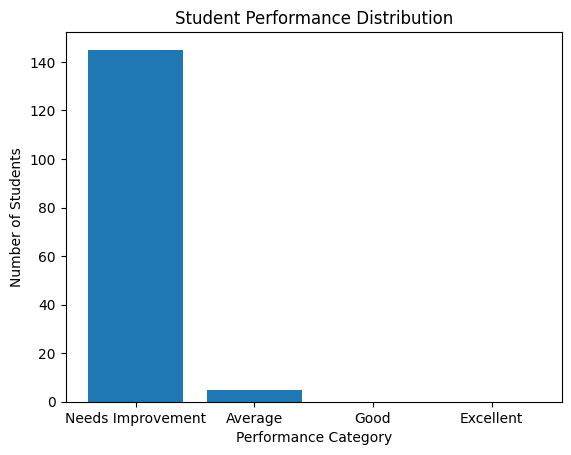

In [35]:
performance_counts=df["Performance_Category"].value_counts()

plt.bar(performance_counts.index,performance_counts.values)

plt.title("Student Performance Distribution")
plt.xlabel("Performance Category")
plt.ylabel("Number of Students")
plt.show()

##Study Hours vs Final Score

In [36]:
df.head(3)

,Student_ID,Gender,Age,Study_Hours,Attendance,Math_Score,Science_Score,English_Score,Computer_Score,Assignment_Score,Previous_Score,Final_Score,Average_Score,Performance_Category
0,STU001,Male,21,5.4,84.5,36.3,41.7,32.4,43.8,87.2,65.2,73.3,38.550,Needs Improvement
1,STU002,Male,18,4.3,85.5,41.4,23.5,26.3,34.7,89.2,63.1,64.3,31.475,Needs Improvement
2,STU003,Female,18,5.7,75.2,32.7,46.4,35.8,44.8,93.3,77.3,77.4,39.925,Needs Improvement


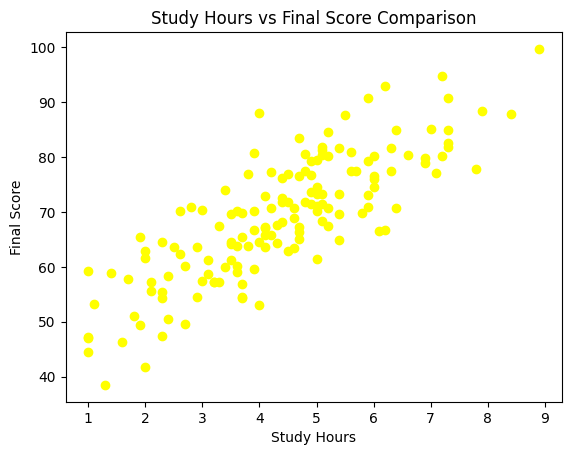

In [40]:
plt.scatter(df["Study_Hours"], df["Final_Score"],color="Yellow")
plt.title("Study Hours vs Final Score Comparison")
plt.xlabel("Study Hours")
plt.ylabel("Final Score")
plt.show()

##Analyzing Attendance vs. Performance 

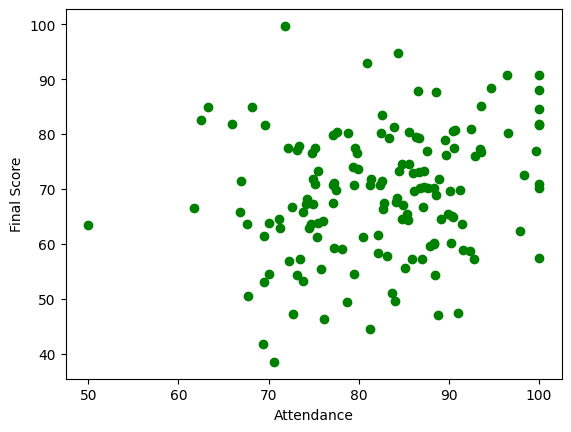

In [43]:
plt.scatter(df["Attendance"], df["Final_Score"],color="Green")
plt.xlabel("Attendance")
plt.ylabel("Final Score")
plt.show()

##Correlation between the two variables

In [46]:
df["Attendance"].corr(df["Final_Score"])

np.float64(0.21578222422020582)

As the correlation is less than 0.5 , it means that there is association between the two but not as strong.

##Distribution of Final Scores

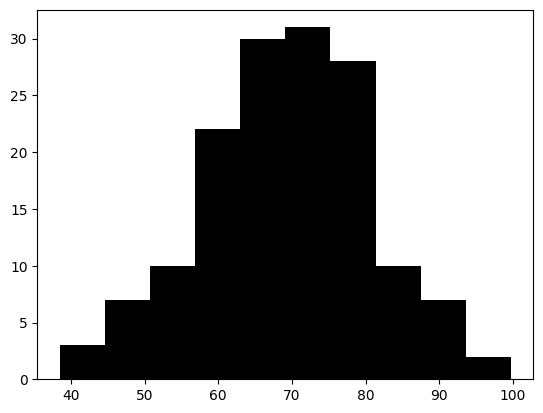

In [44]:
plt.hist(df["Final_Score"],color="Black")
plt.show()

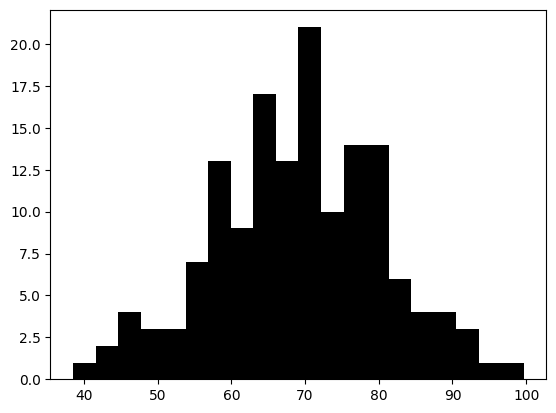

In [45]:
plt.hist(df["Final_Score"],color="Black",bins=20)
plt.show()

##Boxplots for Subjects

In [47]:
df.head(3)

,Student_ID,Gender,Age,Study_Hours,Attendance,Math_Score,Science_Score,English_Score,Computer_Score,Assignment_Score,Previous_Score,Final_Score,Average_Score,Performance_Category
0,STU001,Male,21,5.4,84.5,36.3,41.7,32.4,43.8,87.2,65.2,73.3,38.550,Needs Improvement
1,STU002,Male,18,4.3,85.5,41.4,23.5,26.3,34.7,89.2,63.1,64.3,31.475,Needs Improvement
2,STU003,Female,18,5.7,75.2,32.7,46.4,35.8,44.8,93.3,77.3,77.4,39.925,Needs Improvement


<Axes: ylabel='Math_Score'>

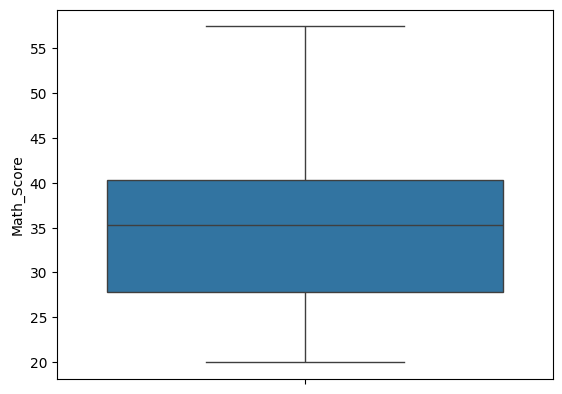

In [48]:
sns.boxplot(df["Math_Score"])

<Axes: ylabel='English_Score'>

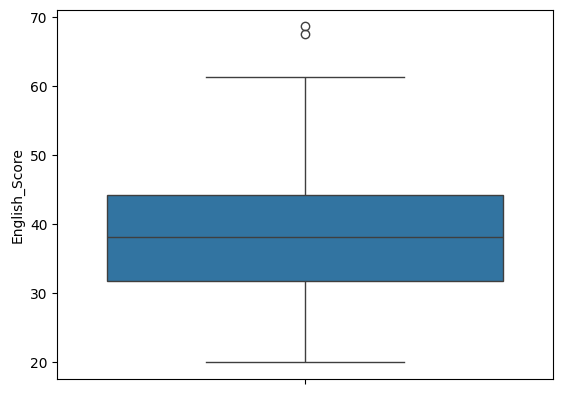

In [49]:
sns.boxplot(df["English_Score"])

<Axes: ylabel='Science_Score'>

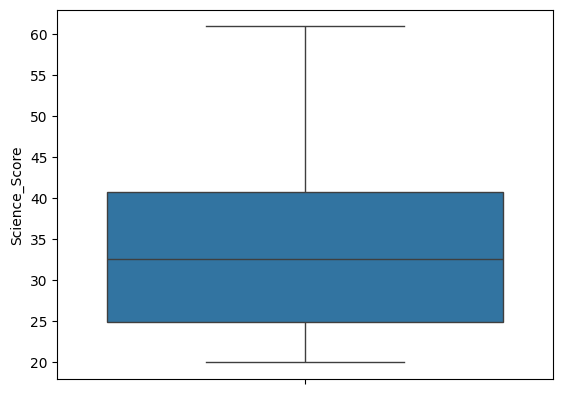

In [50]:
sns.boxplot(df["Science_Score"])

<Axes: ylabel='Computer_Score'>

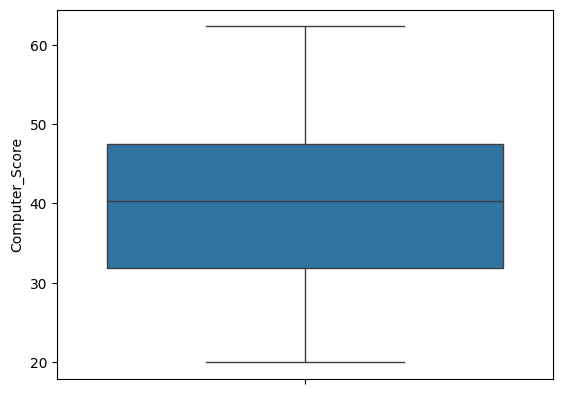

In [51]:
sns.boxplot(df["Computer_Score"])

##Correlation Matrix of the data

<Axes: >

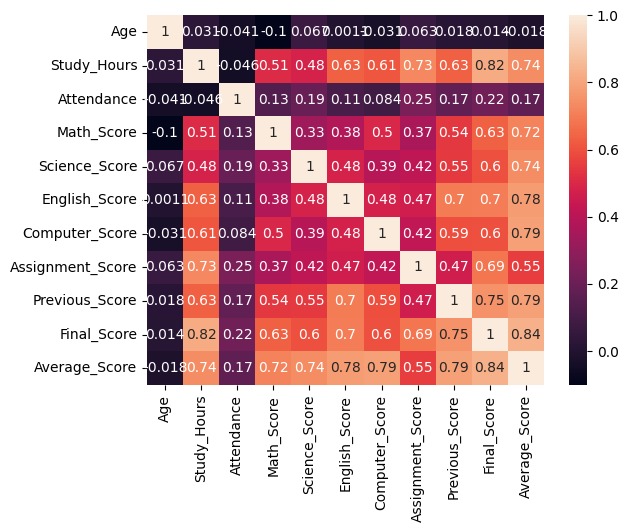

In [52]:
correlation = df.corr(numeric_only=True)
sns.heatmap(correlation,annot=True)

##Business style questions 

- Student Performance
What percentage of students performed well? 
Which subject has the highest average score?
Which subject has the lowest average score?
- Study Habits
Do students who study more score higher?
What is the average study time of high-performing students?
- Attendance
Does attendance appear to affect performance?
What percentage of students have attendance below 75%?
- Academic Progress
How does previous score compare with final score?
Which students improved the most?
- Risk Identification
Can we identify students who may need academic support?

###Student Performance

In [53]:
good_students = df["Performance_Category"].isin(
    ["Good", "Excellent"]
).sum()

percentage = (good_students / len(df)) * 100

print(percentage)

0.0


In [54]:
subject_averages = df[
    ["Math_Score", "Science_Score", "English_Score", "Computer_Score"]
].mean()

print(subject_averages)

Math_Score        34.707333
Science_Score     33.706040
English_Score     38.618667
Computer_Score    40.314000
dtype: float64


In [56]:
subject_averages.max()

np.float64(40.314)

This means computer subject has the highest average compared to others and Science has the lowest average. 

##STudy Habits  

In [57]:
df["Study_Hours"].corr(df["Final_Score"])

np.float64(0.8173235596766656)

(0.82) means there is strong positive correlation b/w the two variables (Study Hours and FInal Score) 
It concludes that the students that study more,score more.

In [58]:
low_attendance = (df["Attendance"] < 75).sum()

percentage = (low_attendance / len(df)) * 100

print(percentage)

24.666666666666668


###Students who have improved the most are:

In [60]:
df["Improvement"] = df["Final_Score"] - df["Previous_Score"]
df.sort_values("Improvement", ascending=False).head(10)

,Student_ID,Gender,Age,Study_Hours,Attendance,Math_Score,Science_Score,English_Score,Computer_Score,Assignment_Score,Previous_Score,Final_Score,Average_Score,Performance_Category,Improvement
82,STU083,Female,21,7.2,82.5,38.8,32.6,34.3,35.6,100.0,61.7,80.2,35.325,Needs Improvement,18.5
9,STU010,Male,21,5.5,88.6,30.1,51.2,46.6,61.0,90.9,71.3,87.6,47.225,Needs Improvement,16.3
131,STU132,Female,22,4.6,88.6,28.0,20.5,29.6,22.0,98.8,53.0,68.9,25.025,Needs Improvement,15.9
96,STU097,Female,19,5.0,77.3,36.2,32.5,35.6,50.0,79.4,55.2,71.1,38.575,Needs Improvement,15.9
36,STU037,Male,21,4.9,86.7,30.3,40.9,43.3,31.3,97.1,63.6,79.2,36.450,Needs Improvement,15.6
91,STU092,Male,18,6.2,80.9,33.7,51.2,49.5,30.4,100.0,78.3,92.9,41.200,Needs Improvement,14.6
144,STU145,Female,21,5.0,85.6,42.6,36.9,45.9,36.9,78.8,60.0,74.6,40.575,Needs Improvement,14.6
33,STU034,Male,19,2.6,86.8,29.2,21.8,33.9,20.0,92.9,55.6,70.1,26.225,Needs Improvement,14.5
29,STU030,Female,18,4.0,100.0,47.7,46.5,45.0,42.2,96.0,74.0,88.0,45.350,Needs Improvement,14.0
138,STU139,Female,19,6.0,84.8,43.2,49.6,42.7,42.4,98.5,60.6,74.6,44.475,Needs Improvement,14.0


This gives the 10 students that improved the most. Now lets find the one who improved the most among them

In [61]:
df["Improvement"].max()
df.loc[df["Improvement"].idxmax()]

Student_ID                         STU083
Gender                             Female
Age                                    21
Study_Hours                           7.2
Attendance                           82.5
Math_Score                           38.8
Science_Score                        32.6
English_Score                        34.3
Computer_Score                       35.6
Assignment_Score                    100.0
Previous_Score                       61.7
Final_Score                          80.2
Average_Score                      35.325
Performance_Category    Needs Improvement
Improvement                          18.5
Name: 82, dtype: object

##Risk Identification (Students requiring academic support)

In [64]:
at_risk = df[
    (df["Attendance"] < 75) &
    (df["Final_Score"] < 50)
]

In [65]:
print(at_risk)

    Student_ID  Gender  Age  Study_Hours  Attendance  Math_Score  \
49      STU050    Male   22          1.3        70.6        20.0   
100     STU101  Female   21          2.0        69.4        20.4   
110     STU111    Male   18          1.0        72.7        25.5   

     Science_Score  English_Score  Computer_Score  Assignment_Score  \
49            25.5           23.5            27.2              68.6   
100           20.0           20.0            34.9              62.4   
110           23.1           26.6            37.7              47.9   

     Previous_Score  Final_Score  Average_Score Performance_Category  \
49             51.2         38.5         24.050    Needs Improvement   
100            42.7         41.7         23.825    Needs Improvement   
110            57.8         47.2         28.225    Needs Improvement   

     Improvement  
49         -12.7  
100         -1.0  
110        -10.6  


In [66]:
len(at_risk)

3

In [67]:
(len(at_risk)/len(df)) * 100

2.0

Two percent of them need academic support.

#Key Findings

- Finding 1: Computer Science had the highest average score among the four subjects.

- Finding 2: Students with higher attendance generally demonstrated better final performance.

- Finding 3: Study hours showed a positive relationship with final scores.

- Finding 4: STU050,STU101 and STU111 students were identified as potentially at risk based on low attendance and final scores.